# Brain Tumor MRI Classification using PyTorch

---
#### DISCLAIMER: THIS IS NOT MEDICAL ADVICE, DO NOT SELF DIAGNOSE

## Imports and loading data

In [1]:
import torch
from torch import nn, optim
from torch.nn import Flatten
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

# use gpu if it's available if not cpu which is much slower
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Image transformations
Certain transformations are needed before using an image, e.g resize, changing to tensor and normalizing

In [2]:
# Every image will go through this transformation pipeline
pic_trans = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [3]:
train_dl = DataLoader(
    datasets.ImageFolder('data/Training', pic_trans),
    batch_size=32,
    shuffle=True,
    num_workers=4, # speeds up loading data
    pin_memory=True
)

test_dl = DataLoader(
    datasets.ImageFolder('data/Testing', pic_trans),
    batch_size=32,
    shuffle=False, # there is no need to shuffle, as this is just for evaluation
    num_workers=4, # speeds up loading data
    pin_memory=True
)

## Define model

In [4]:
model = nn.Sequential(
    nn.Conv2d(3, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(32, 64, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(64, 128, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(128 * 16 * 16, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 4) # final layer, which takes 256 as input and 4 as output (4 classes
).to(device)

In [5]:
opt = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

## Training loop

In [7]:
for epoch in range(25):
    running_loss = 0

    for x, y in train_dl:
        opt.zero_grad()

        loss = loss_fn(model(x.to(device)), y.to(device))
        loss.backward()

        running_loss += loss.item()
        opt.step()

    print(f'Epoch {epoch+1}: Loss was {running_loss}')

Epoch 1: Loss was 51.45771186053753
Epoch 2: Loss was 38.74792783334851
Epoch 3: Loss was 28.658228199929
Epoch 4: Loss was 24.898877115920186
Epoch 5: Loss was 18.18314202921465
Epoch 6: Loss was 13.974187729181722
Epoch 7: Loss was 12.372916403692216
Epoch 8: Loss was 11.330279793706723
Epoch 9: Loss was 7.588389152078889
Epoch 10: Loss was 8.463843477831688
Epoch 11: Loss was 6.112934112839866
Epoch 12: Loss was 4.944278866634704
Epoch 13: Loss was 6.563762408499315
Epoch 14: Loss was 4.762613176571904
Epoch 15: Loss was 7.509702373179607
Epoch 16: Loss was 4.339437063717924
Epoch 17: Loss was 3.630792562948045
Epoch 18: Loss was 6.905966447191531
Epoch 19: Loss was 5.3963842935772846
Epoch 20: Loss was 2.943088057480054
Epoch 21: Loss was 3.4716388132437714
Epoch 22: Loss was 4.357511259597231
Epoch 23: Loss was 4.520925314245687
Epoch 24: Loss was 4.087646187563223
Epoch 25: Loss was 4.9131970499656745


In [8]:
model.eval()
test_loss, correct = 0.0, 0
with torch.no_grad():
    for x, y in test_dl:
        y, y = x.to(device), y.to(device)

        logits = model(x)
        test_loss = loss_fn(logits, y).item() * y.size(0)

        preds = logits.argmax(dim=1)
        correct += (preds == y).float().sum().item()

test_loss /= len(test_dl.dataset)
accuracy = 100.0 * correct / len(test_dl.dataset)

print(f'Test set: Average loss: {test_loss}, Accuracy: {accuracy}')

Test set: Average loss: 0.001755879670381546, Accuracy: 90.3125


Decent with room for improvement ;))

## Visualising image

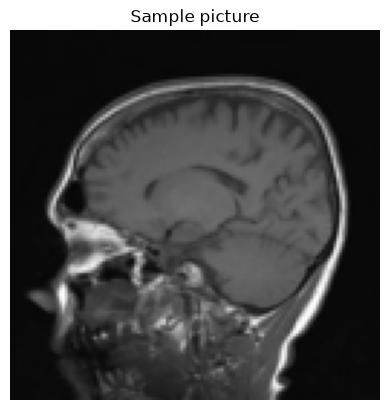

Predicted: notumor
Actual: notumor


In [10]:
import random
from torchvision.transforms.functional import to_pil_image

model.eval()

idx = random.randrange(len(test_dl.dataset))
img, label = test_dl.dataset[idx]

unnorm = img * 0.5 + 0.5
plt.imshow(to_pil_image(unnorm))
plt.axis('off')
plt.title('Sample picture')
plt.show()

with torch.no_grad():
    logits = model(img.unsqueeze(0).to(device))
    pred = logits.argmax(dim=1).item()

class_names = test_dl.dataset.classes
print(f'Predicted: {class_names[pred]}')
print(f'Actual: {class_names[label]}')

## Conclusion
Model is decent but there is room for improvement. Hyperparameter tuning, trying different architectures and optimisers, learning rates, model checkpointing.